<a href="https://colab.research.google.com/github/Vyshnavi015/Vyshnavi015/blob/main/weathermodeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

# Creating a sample dataset
data = {
    'Day': [1,2,3,4,5,6,7,8,9,10],
    'Temperature': [15,18,21,24,28,27,25,22,20,18]
}

df = pd.DataFrame(data)

# Save to CSV
df.to_csv('multipleval.csv', index=False)

print("Sample CSV file 'multipleval.csv' created.")


Sample CSV file 'multipleval.csv' created.


Root Mean Squared Error: 1.118


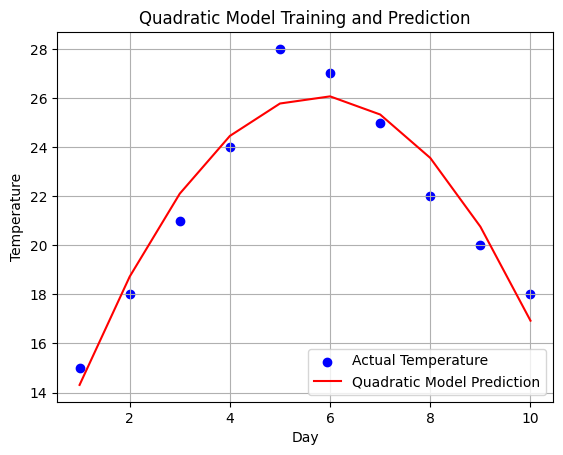

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Load data from CSV (assumes columns: Day, Temperature)
file_path = "multipleval.csv"
df = pd.read_csv(file_path)

# Take first 10 days for training
df = df.head(10)

X = df[['Day']].values  # Days as input feature (reshaped to 2D)
y = df['Temperature'].values  # Actual temperature values

# Create polynomial features (degree=2 for quadratic)
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

# Train linear regression on polynomial features
model = LinearRegression()
model.fit(X_poly, y)

# Predict using the trained model
y_pred = model.predict(X_poly)

# Calculate RMSE as performance metric
rmse = np.sqrt(mean_squared_error(y, y_pred))
print(f"Root Mean Squared Error: {rmse:.3f}")

# Plot actual vs predicted temperatures
plt.scatter(X, y, color='blue', label='Actual Temperature')
plt.plot(X, y_pred, color='red', label='Quadratic Model Prediction')
plt.xlabel('Day')
plt.ylabel('Temperature')
plt.title('Quadratic Model Training and Prediction')
plt.legend()
plt.grid(True)
plt.show()
